In [10]:
import json, joblib, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [11]:
def get_contour_data(x, y):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
        # Estimate density
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    
    # Create a grid and evaluate density on it
    x_grid = np.linspace(x.min(), x.max(), 100)
    y_grid = np.linspace(y.min(), y.max(), 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    return X, Y, Z

In [12]:
def all_gpcr_plot_base():
    PREFIX = "backbone"
    pca  = joblib.load(f"{PREFIX}_pca.joblib")
    proj = np.load(f"{PREFIX}_train_projections.npy")
    with open(f"{PREFIX}_meta.json") as f:
        meta = json.load(f)
    codes    = meta["codes_retained"]
    str_meta = meta["structure_meta"]
    states   = [str_meta[c].get("state", "Unknown") for c in codes]
    marker_spec = {"Active": "^", "Inactive": "v", "Intermediate": "s"}
    color_spec  = {"Active":  (0.1, 0.6, 0.1),
                   "Inactive": (0.6, 0.1, 0.1),
                   "Intermediate": (0.1, 0.1, 0.6)}
    fig, ax = plt.subplots(figsize=(7, 6))
    for x, y, state in zip(proj[:, 0], proj[:, 1], states):
        ax.scatter(x, y, marker=marker_spec.get(state, "o"),
                   color=color_spec.get(state, (0.5, 0.5, 0.5)),
                   alpha=0.7, s=40)
    legend_handles = [
        Line2D([0], [0], marker=m, color=color_spec[s],
               linestyle="None", markersize=9, label=s)
        for s, m in marker_spec.items()
    ]
    ax.legend(handles=legend_handles, title="State",
              bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title("GPCR PCA — Xtal/Cryo Structures")
    return fig, ax

In [30]:
def plot_additional_projections(projections, fig, ax, n_levels=6):
    for i, projection in enumerate(projections):
        X, Y, Z = get_contour_data(projection[:, 0], projection[:, 1])
        if i ==0:
            cols = [((n_levels - i) / n_levels, 0.08, 0.08) for i in range(n_levels)][::-1]
        elif i ==1:
            cols = [(0.08, (n_levels - i) / n_levels, 0.08) for i in range(n_levels)][::-1]
        elif i ==2:
            cols = [(0.08, 0.08, (n_levels - i) / n_levels) for i in range(n_levels)][::-1]
        contour = ax.contour(X, Y, Z, levels=n_levels, colors=cols)

def add_projection(projection, n_levels=6, cols='r'):
    X, Y, Z = get_contour_data(projection[:, 0], projection[:, 1])
    contour = ax.contour(X, Y, Z, levels=n_levels, colors=cols)

In [33]:
import glob

Text(0.5, 1.0, 'GPCR PCA — 5HT2A - Multiple Ligands')

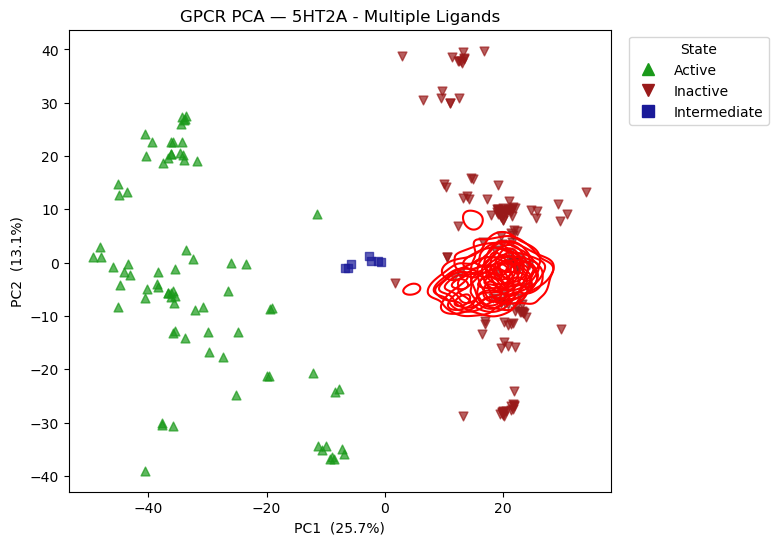

In [34]:
#KOR / GR89696
fig, ax = all_gpcr_plot_base()
#projections = [np.load(f'pca_projections_backbone/5HT2A_rpt{i}.npy') for i in range(3)]
projections = [np.load(fn) for fn in glob.glob('pca_projections_backbone/5HT2A*.npy')]
_ = [add_projection(projection) for projection in projections]
ax.set_title("GPCR PCA — 5HT2A - Multiple Ligands")

In [15]:
def search_for_target(target, root):
    """
    Recursively search through directories, rooting from "root" to discover directories
    containing the "target" string
    """
    return [str(match.resolve()) for match in [path for path in Path(root).rglob('*'+target+'*') if path.is_dir() or path.is_file()]]

In [16]:
os.system('python project_pca_gpcrs.py --help')

usage: project_pca_gpcrs.py [-h] --pdb_code PDB_CODE --topology TOPOLOGY
                            [--trajectory TRAJECTORY] [--chain CHAIN]
                            [--prefix PREFIX] [--stor_dir STOR_DIR]
                            [--resid_offset RESID_OFFSET] [--out OUT]
                            [--verbose]

Project MD trajectory (or single structure) frames onto a pre-computed GPCR PCA space.

The protein's BW mapping is always fetched fresh from GPCRdb — it is never
assumed to be part of the training set.

The key assumption is that residue numbers in the topology/trajectory match
the UniProt sequence numbers used by GPCRdb (this is typically true when the
MD system was built directly from an RCSB PDB file without renumbering).
If your system uses different residue numbering, see --resid_offset.

Outputs:
  <out>   — numpy .npy array, shape (n_frames, n_pcs)

Usage examples:
  # MD trajectory
  python project_pca_gpcrs.py \
      --pdb_code 6CMO --topology system.pdb --tr

0

In [17]:
def run_project_to_pca(pdb_code, top_fn, traj_fn, out_fn, prefix='backbone'):
    command_string = f"python project_pca_gpcrs.py --pdb_code {pdb_code} "
    command_string += f"--topology {top_fn} --trajectory {traj_fn} "
    command_string += f"--prefix {prefix} --out {out_fn}"
    os.system(command_string)

def last_trj_from_svd_vars(svd_var_dir):
    last_sim_dir = os.path.join(svd_var_dir, sorted(os.listdir(svd_var_dir), key=lambda x: int(x))[-1])
    trj_fn = os.path.join(last_sim_dir, 'resampled_trj.dcd')
    return trj_fn

In [24]:
direcs = ['/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/6wha_2.0x1.0/saved_variables',
          '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/7voe_fixed_2.0x1.0/saved_variables',
          '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/8JT8_2.0x1.0/saved_variables',
          '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7vod_2.0x1.0/saved_variables',
          '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc4_2.0x1.0/saved_variables',
          '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc5_2.0x1.0/saved_variables',
          '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc6_2.0x1.0/saved_variables',
          '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc7_2.0x1.0/saved_variables',
          ]

pdbs = ['/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/6wha.pdb',
        '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/7voe.pdb',
        '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/8JT8.pdb',
        '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7vod.pdb',
        '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb',
        '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc5.pdb',
        '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc6.pdb',
        '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc7.pdb',
       ]

codes = ['6WHA', '7VOE', '8JT8', '7VOD', '7WC4', '7WC5', '7WC6', '7WC7']

In [25]:
# trj_fns = [last_trj_from_svd_vars(f'/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_{i}/saved_variables') for i in [0,1,2]]
# False in [os.path.isfile(trjfn) for trjfn in trj_fns]

trj_fns = [last_trj_from_svd_vars(direc) for direc in direcs]
False in [os.path.isfile(trjfn) for trjfn in trj_fns]

False

In [26]:
trj_fns

['/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/6wha_2.0x1.0/saved_variables/47/resampled_trj.dcd',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/7voe_fixed_2.0x1.0/saved_variables/53/resampled_trj.dcd',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/8JT8_2.0x1.0/saved_variables/44/resampled_trj.dcd',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7vod_2.0x1.0/saved_variables/53/resampled_trj.dcd',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc4_2.0x1.0/saved_variables/53/resampled_trj.dcd',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc5_2.0x1.0/saved_variables/52/resampled_trj.dcd',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc6_2.0x1.0/saved_variables/48/resampled_trj.dcd',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc7_2.0

In [27]:
#top_fn = '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb'
#pdb_code = '7WC4'
#out_fns = [f'pca_projections_backbone/serotonin7wc4_rpt{i}' for i in [0,1,2]]

In [28]:
# for trj_fn, out_fn in zip(trj_fns, out_fns):
#     run_project_to_pca(pdb_code, top_fn, trj_fn, out_fn)

In [29]:
for trj_fn, top_fn, pdb_code in zip(trj_fns, pdbs, codes):
    print(trj_fn, top_fn, pdb_code)
    run_project_to_pca(pdb_code=pdb_code, top_fn=top_fn, traj_fn=trj_fn, out_fn=f"pca_projections_backbone/5HT2A_{pdb_code}.npy")

/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/6wha_2.0x1.0/saved_variables/47/resampled_trj.dcd /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/6wha.pdb 6WHA


/home/josephdb/miniconda3/envs/replica2/lib/python3.12/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
Traceback (most recent call last):
  File "/expanse/lustre/projects/uil133/josephdb/ChiMPSS/project_pca_gpcrs.py", line 552, in <module>
    main()
  File "/expanse/lustre/projects/uil133/josephdb/ChiMPSS/project_pca_gpcrs.py", line 485, in main
    raise Exception(
Exception: 48 conserved BW positions are missing from this structure — too many for mean imputation (limit: 2).
  [6.47] GPCRdb seqnum 335 → trajectory resid 335 not found
  [6.48] GPCRdb seqnum 336 → trajectory resid 336 not found
  [6.49] G

Loaded PCA: 218 components, trained on 218 structures
Selection : 'backbone'  |  Expected atoms: 884
Fetching GPCRdb data for 6WHA...
  Protein slug: 5ht2a_human  |  471 residues in BW map
Universe  : 1000 frame(s), 63627 atoms
Mapping conserved BW positions to trajectory residues...
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/7voe_fixed_2.0x1.0/saved_variables/53/resampled_trj.dcd /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/7voe.pdb 7VOE
Loaded PCA: 218 components, trained on 218 structures
Selection : 'backbone'  |  Expected atoms: 884
Fetching GPCRdb data for 7VOE...
  Protein slug: 5ht2a_human  |  471 residues in BW map


Traceback (most recent call last):
  File "/expanse/lustre/projects/uil133/josephdb/ChiMPSS/project_pca_gpcrs.py", line 552, in <module>
    main()
  File "/expanse/lustre/projects/uil133/josephdb/ChiMPSS/project_pca_gpcrs.py", line 462, in main
    u = mda.Universe(args.topology, args.trajectory)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/josephdb/miniconda3/envs/replica2/lib/python3.12/site-packages/MDAnalysis/core/universe.py", line 569, in __init__
    topology = _topology_from_file_like(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/josephdb/miniconda3/envs/replica2/lib/python3.12/site-packages/MDAnalysis/core/universe.py", line 239, in _topology_from_file_like
    raise sys.exc_info()[1] from err
  File "/home/josephdb/miniconda3/envs/replica2/lib/python3.12/site-packages/MDAnalysis/core/universe.py", line 229, in _topology_from_file_like
    topology = p.parse(**kwargs)
               ^^^^^^^^^^^^^^^^^
  File "/home/josephdb/miniconda3/envs/repli

/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/8JT8_2.0x1.0/saved_variables/44/resampled_trj.dcd /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/8JT8.pdb 8JT8


...

Loaded PCA: 218 components, trained on 218 structures
Selection : 'backbone'  |  Expected atoms: 884
Fetching GPCRdb data for 7WC5...
  Protein slug: 5ht2a_human  |  471 residues in BW map
Universe  : 1000 frame(s), 46339 atoms
Mapping conserved BW positions to trajectory residues...
  All 221 conserved positions mapped successfully
Selected  : 884 atoms (221 residues present)
Projecting 1000 frame(s)...
  1000/1000

Saved projections → pca_projections_backbone/5HT2A_7WC5.npy  shape: (1000, 218)
  PC1  [1.62, 30.91]
  PC2  [-10.91, 4.29]
  PC3  [-7.80, 27.61]
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc6_2.0x1.0/saved_variables/48/resampled_trj.dcd /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc6.pdb 7WC6


/home/josephdb/miniconda3/envs/replica2/lib/python3.12/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Loaded PCA: 218 components, trained on 218 structures
Selection : 'backbone'  |  Expected atoms: 884
Fetching GPCRdb data for 7WC6...
  Protein slug: 5ht2a_human  |  471 residues in BW map
Universe  : 1000 frame(s), 44308 atoms
Mapping conserved BW positions to trajectory residues...

    [1.32] GPCRdb seqnum 74 → trajectory resid 74 not found
  PC1 loading norm from imputed features: 0.2%
  PC2 loading norm from imputed features: 0.3%

Selected  : 880 atoms (220 residues present, 1 imputed)
Projecting 1000 frame(s) [mean imputation active]...
  1000/1000

Saved projections → pca_projections_backbone/5HT2A_7WC6.npy  shape: (1000, 218)
  PC1  [9.71, 33.94]
  PC2  [-14.70, 6.38]
  PC3  [-5.21, 18.32]
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc7_2.0x1.0/saved_variables/53/resampled_trj.dcd /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc7.pdb 7WC7


/home/josephdb/miniconda3/envs/replica2/lib/python3.12/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Loaded PCA: 218 components, trained on 218 structures
Selection : 'backbone'  |  Expected atoms: 884
Fetching GPCRdb data for 7WC7...
  Protein slug: 5ht2a_human  |  471 residues in BW map
Universe  : 1000 frame(s), 45957 atoms
Mapping conserved BW positions to trajectory residues...
  All 221 conserved positions mapped successfully
Selected  : 884 atoms (221 residues present)
Projecting 1000 frame(s)...
  1000/1000

Saved projections → pca_projections_backbone/5HT2A_7WC7.npy  shape: (1000, 218)
  PC1  [5.88, 28.07]
  PC2  [-11.60, 10.55]
  PC3  [-5.42, 17.17]


In [36]:
np.load('7WC4_projections.npy')[:, :2]

array([[21.669497  ,  0.07134628]], dtype=float32)

In [29]:
sorted(search_for_target('saved_variables', '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/'))

['/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_0/saved_variables',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_1/saved_variables',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_2/saved_variables',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2b_lsd_7srq_2.0x1.0/saved_variables',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2b_lsd_7srr_2.0x1.0/saved_variables',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/AM630_retro_convergence/anna_rpt_1/saved_variables',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25-N-NBI_2.0x1.0/saved_variables',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-N1-Nap_2.0x1.0/saved_variables',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBOMe_2.0x1.0/saved_variables',
 '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aima

In [40]:
[sorted(search_for_target('saved_variables', '/expanse/lustre/projects/uil133/josephdb/')),
 sorted(search_for_target('Step_5', '/expanse/lustre/projects/uil133/josephdb/'))]

[['/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_0/saved_variables',
  '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_1/saved_variables',
  '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_2/saved_variables',
  '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2b_lsd_7srq_2.0x1.0/saved_variables',
  '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2b_lsd_7srr_2.0x1.0/saved_variables',
  '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/AM630_retro_convergence/anna_rpt_1/saved_variables',
  '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25-N-NBI_2.0x1.0/saved_variables',
  '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-N1-Nap_2.0x1.0/saved_variables',
  '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBOMe_2.0x1.0/saved_variables',
  '/expanse/lustre/projects/uil133/josephdb/Analysis

In [38]:
[sorted(search_for_target('saved_variables', '/expanse/lustre/projects/iit122/jhermes/')),
 sorted(search_for_target('Step_5', '/expanse/lustre/projects/iit122/jhermes/'))]

[['/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/6GNTI/0_0/saved_variables',
  '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/A1BNM/0_0/saved_variables',
  '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/APO/0_0/saved_variables',
  '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/Akuammicine/0_0/saved_variables',
  '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/CSDace18NH2/0_0/saved_variables',
  '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/Cyclazocine--/0_0/saved_variables',
  '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/DNCP_b_NalA_1/0_0/saved_variables',
  '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/Difelikefalin/0_0/saved_variables',
  '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/Diprenorphine/0_0/saved_variables',
  '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/DynA_1_13/0_0/saved_variables',
  '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/DynA_1_13_out/

In [46]:
[sorted(search_for_target('saved_variables', '/expanse/lustre/projects/iit124/tnguyen7/')),
 sorted(search_for_target('sys.xml', '/expanse/lustre/projects/iit124/tnguyen7/'))]

[['/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/9THC_0/saved_variables',
  '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/AM630_0/saved_variables',
  '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/AM630_1/saved_variables',
  '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/AM630_2/saved_variables',
  '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/CP55940_0/saved_variables',
  '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/FMP7234691_0/saved_variables',
  '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/HU210_0/saved_variables',
  '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/HU308_0/saved_variables',
  '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/JWH133_0/saved_variables',
  '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/R-AM1241_0/saved_variables',
  '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/RO5135445_0/saved_variables',
  '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/RO6843766_0/saved_variables'

In [48]:
[sorted(search_for_target('saved_variables', '/expanse/lustre/projects/iit122/akhan3/')),
 sorted(search_for_target('sys.xml', '/expanse/lustre/projects/iit122/akhan3/'))]

[['/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2C_replica_exchange/5HT2C/8DPGGG_0/saved_variables',
  '/expanse/lustre/projects/iit122/akhan3/5HT2A/J_paper/replica_exchange/fixed_7wc4_1/saved_variables',
  '/expanse/lustre/projects/iit122/akhan3/5HT2A/J_paper/replica_exchange2/fixed_7wc4_2/saved_variables',
  '/expanse/lustre/projects/iit122/akhan3/5HT2A/new_replica_exchange/three_1500/25N-N1-Nap_0/saved_variables',
  '/expanse/lustre/projects/iit122/akhan3/5HT2A/new_replica_exchange/three_1500/IHCH-7086_analogue_0/saved_variables',
  '/expanse/lustre/projects/iit122/akhan3/5HT2A/new_replica_exchange/three_1500/IHCH-7089_analogue_0/saved_variables',
  '/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25-N-NBI_0/saved_variables',
  '/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25N-N1-Nap_0/saved_variables',
  '/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25N-NBOMe_0/saved_variables',
  '/expanse/lustre/projects/iit122/akhan3/5HT2A/repli

In [17]:
mydir

'/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Anna_CB2_Full/SR144528_2.0x1.0/saved_variables'

In [18]:
ll /expanse/lustre/projects/uil133/josephdb/

total 16714
-rw-r--r--  1 josephdb  388693 Mar 29 20:09 _00_anna_resampled.pdb
-rw-r--r--  1 josephdb    6371 Mar 11 13:04 47206483.exp-12-59.MPI_REPEX.out
-rw-r--r--  1 josephdb   18047 Mar 11 14:06 47239767.exp-7-59.ONE_REPEX.out
-rw-r--r--  1 josephdb 5310279 Mar 13 18:18 47241809.exp-8-59.MPI_REPEX.out
-rw-r--r--  1 josephdb 5240581 Mar 14 04:00 47241810.exp-1-60.MPI_REPEX.out
-rw-r--r--  1 josephdb 5286731 Mar 14 04:28 47241811.exp-10-59.MPI_REPEX.out
-rw-r--r--  1 josephdb     247 Mar 23 11:54 47620758.exp-5-33.distancematrix.out
-rw-r--r--  1 josephdb 1103116 Mar 25 02:29 47630220.exp-12-59.MPI_REPEX.out
-rw-r--r--  1 josephdb 1478817 Mar 25 13:26 47630233.exp-6-60.MPI_REPEX.out
-rw-r--r--  1 josephdb 1094949 Mar 25 10:48 47630248.exp-8-59.MPI_REPEX.out
-rw-r--r--  1 josephdb   61275 Mar 27 15:53 47669040.exp-13-58.ONE_REPEX.out
-rw-r--r--  1 josephdb   61248 Mar 27 15:58 47669041.exp-3-58.ONE_REPEX.out
-rw-r--r--  1 josephdb   61265 Mar 27 15:54 47669042.exp-12-60.ONE_REPEX.out

In [1]:
from chimpss.analysis.gpcr_pca import Structure_Analyzer


In [2]:
with open('612_gpcrs.txt', 'r') as f:
    pdb_ids = sorted(f.read().split('\n'))

In [3]:
tests = [Structure_Analyzer(pdb_id, stor_dir='./many_structures/') for pdb_id in pdb_ids]

In [4]:
for test in tests:
    print(test.pdb_code, test)
    start = datetime.now()
    test.request_structure_info()
    test.request_rcsb_pdb(and_load=False)
    test.request_gene_info()
    test.request_naming_info()
    test.request_gene_structure_alignment()
    d_T = datetime.now() - start
    #test.getSchemeNames()
    #test.getPrimarySequence()
    print(f"Time for four requests was: {d_T}")

1F88 <__main__.Structure_Analyzer object at 0x7994794739b0>
Time for four requests was: 0:00:05.292479
1GZM <__main__.Structure_Analyzer object at 0x7994ecb50410>
Time for four requests was: 0:00:04.699833
1HZX <__main__.Structure_Analyzer object at 0x7994ecb50440>
Time for four requests was: 0:00:04.905289
1L9H <__main__.Structure_Analyzer object at 0x7994ecb511c0>
Time for four requests was: 0:00:04.691056
1U19 <__main__.Structure_Analyzer object at 0x79947f9b5ca0>
Time for four requests was: 0:00:04.791379
2G87 <__main__.Structure_Analyzer object at 0x7994ecba5190>
Time for four requests was: 0:00:04.870543
2HPY <__main__.Structure_Analyzer object at 0x7994ecba5100>
Time for four requests was: 0:00:04.992869
2I35 <__main__.Structure_Analyzer object at 0x7994ecba5010>
Time for four requests was: 0:00:04.534157
2I36 <__main__.Structure_Analyzer object at 0x7994ecba5220>
Time for four requests was: 0:00:04.971803
2I37 <__main__.Structure_Analyzer object at 0x7994ecba5310>
Time for four

In [5]:
len(tests)

612

In [6]:
uni_BW_maps = {}
for test in tests:
    try:
        uni_BW_maps[test.pdb_code] = test.getSchemeNames()
    except:
        print('error on BW names for', test.pdb_code)

In [7]:
uni_Wootten_maps = {}
for test in tests:
    try:
        uni_Wootten_maps[test.pdb_code] = test.getSchemeNames(scheme='Wootten')
    except:
        print('error on BW names for', test.pdb_code)

error on BW names for 6LFL
error on BW names for 6LFM
error on BW names for 6LFO


In [8]:
cryo_primary_seqs = {}
for test in tests:
    try:
        cryo_primary_seqs[test.pdb_code] = test.getPrimarySequence()
    except:
        print('error on ', test.pdb_code)

/home/exouser/miniconda3/envs/bpsim/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:479: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn(
/home/exouser/miniconda3/envs/bpsim/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


error on  6YVR
error on  6Z4Q
error on  6Z4S
error on  6Z4V
error on  6Z66
error on  6Z8N
error on  6ZA8
error on  6ZIN
error on  7B6W


In [9]:
for test in tests:
    try:
        _ = test.load_pdb()
    except:
        print(f"error on", test.pdb_code)

error on 6YVR
error on 6Z4Q
error on 6Z4S
error on 6Z4V
error on 6Z66
error on 6Z8N
error on 6ZA8
error on 6ZIN
error on 7B6W


In [10]:
BW_assignments = {}
for test in tests: #A dictionary of dictionaries...
    try:
        BW_assignments[test.pdb_code] = {}
        for resid in test.backbone.select_atoms('name CA').residues.resids:
            try:
                BW_assignments[test.pdb_code][resid] = uni_BW_maps[test.pdb_code][resid]
            except KeyError:
                #Those silly crystallographers provided a non-uniprot index...
                pass
    except:
        print('error on', test.pdb_code)

error on 6YVR
error on 6Z4Q
error on 6Z4S
error on 6Z4V
error on 6Z66
error on 6Z8N
error on 6ZA8
error on 6ZIN
error on 7B6W


In [11]:
#PDBS failing some kind of test...
test_ids = [test.pdb_code for test in tests]

key_sets = []
for that_dict in [uni_BW_maps, cryo_primary_seqs, BW_assignments]:
    key_sets += [key for key in test_ids if key not in that_dict.keys()]
np.unique(key_sets)

array(['6YVR', '6Z4Q', '6Z4S', '6Z4V', '6Z66', '6Z8N', '6ZA8', '6ZIN',
       '7B6W'], dtype='<U4')

In [12]:
raise Exception('PAUSE')

Exception: PAUSE

In [32]:
#Count the unique assignments, and conservation %
n_structures = len(tests)
unique_bws = {}
for pdb_code, assignments in BW_assignments.items():
    for assignment in assignments.values():
        if assignment == '-1': #Don't bother
            continue
        elif assignment not in unique_bws.keys(): #First time?
            unique_bws[assignment] = 1
        else: #Not my first rodeo
            unique_bws[assignment] += 1

unique_bws = {key: [val, round(val/n_structures, 2)] for key, val in dict(sorted(unique_bws.items())).items()}

In [33]:
print(unique_bws)

{'1.20': [4, 0.01], '1.21': [4, 0.01], '1.22': [15, 0.02], '1.23': [16, 0.03], '1.24': [51, 0.08], '1.25': [66, 0.11], '1.26': [69, 0.11], '1.27': [132, 0.22], '1.28': [289, 0.47], '1.29': [354, 0.58], '1.30': [412, 0.67], '1.31': [453, 0.74], '1.32': [513, 0.84], '1.33': [550, 0.9], '1.34': [557, 0.91], '1.35': [583, 0.95], '1.36': [589, 0.96], '1.37': [589, 0.96], '1.38': [591, 0.97], '1.39': [591, 0.97], '1.40': [591, 0.97], '1.41': [591, 0.97], '1.42': [592, 0.97], '1.43': [592, 0.97], '1.44': [591, 0.97], '1.45': [589, 0.96], '1.46': [589, 0.96], '1.47': [589, 0.96], '1.48': [589, 0.96], '1.49': [590, 0.96], '1.50': [590, 0.96], '1.51': [590, 0.96], '1.52': [590, 0.96], '1.53': [590, 0.96], '1.54': [590, 0.96], '1.55': [590, 0.96], '1.56': [590, 0.96], '1.57': [590, 0.96], '1.58': [588, 0.96], '1.59': [579, 0.95], '1.60': [570, 0.93], '1.61': [41, 0.07], '1.62': [9, 0.01], '1.63': [7, 0.01], '1.64': [7, 0.01], '12.47': [4, 0.01], '12.48': [484, 0.79], '12.49': [485, 0.79], '12.50'

In [45]:
bws_above_thresh = [key for key, val in unique_bws.items() if val[-1] > 0.90]

In [51]:
#First ans last of each helix
helices = np.unique(sorted([elem.split('.')[0] for elem in bws_above_thresh]))
for h in helices:
    reses = [elem for elem in bws_above_thresh if elem.split('.')[0] == h]
    print(reses[0], reses[-1],
          eval(f"1+{reses[-1].split('.')[-1]}-{reses[0].split('.')[-1]}"), #How many are expected given the first and last
          len(reses)) #How many are actually there

1.34 1.60 27 27
2.37 2.66 30 30
3.22 3.56 35 35
4.38 4.62 25 25
5.36 5.67 32 32
6.31 6.61 31 31
7.32 7.55 24 24


In [56]:
#resids above thresh
resids_above_thresh = {test.pdb_code: [[key, val] for key, val in BW_assignments[test.pdb_code].items() if val in bws_above_thresh] for test in tests}

In [86]:
resid_from_assignment = lambda posname, pdbcode: [key for key, val in resids_above_thresh[pdbcode] if val == posname]

In [97]:
import itertools

In [106]:
test_by_pdbcode = lambda pdb_code: tests[[test.pdb_code == pdb_code for test in tests].index(True)]

In [102]:
#This seems like a good basis set 40-60 on each helix (center 50 +/- 10 residues per side)
populated_names = []
for name in [f"{i}.{j}" for i, j in itertools.product(range(1, 8), range(40,61))]:
    resids = [resid_from_assignment(name, test.pdb_code) for test in tests]
    length = len([elem for elem in resids if elem])
    if length > 0:
        if name.endswith('50'):
            print(name, length)
        populated_names.append(name)


resids_copopulated = {} #key pdb code, value resids.  These resids should finally all select the "same" atoms by bw assignment
for test in tests:
    resids = [resid_from_assignment(name, test.pdb_code) for name in populated_names]
    if False not in [len(elem) == 1 for elem in resids]:
        resids_copopulated[test.pdb_code] = resids

1.50 590
2.50 590
3.50 591
4.50 591
5.50 591
6.50 581
7.50 582


In [121]:
selected_backbone = [(pdb_code, test_by_pdbcode(pdb_code).backbone.select_atoms(f"chainid {test_by_pdbcode(pdb_code).meta['structure']['preferred_chain']} and (resid " + " or resid ".join([str(elem[0]) for elem in resids]) + ')')) for pdb_code, resids in resids_copopulated.items()]

In [288]:
values, counts = np.unique([backbone.n_atoms for pdb_code, backbone in selected_backbone], return_counts=True)

In [295]:
test = test_by_pdbcode('6G79')
test.backbone.select_atoms(f"chainid {test.meta['structure']['preferred_chain']} and (resid " + " or resid ".join([str(elem[0]) for elem in resids_copopulated[test.pdb_code]]) + ')')

KeyError: '6G79'

In [291]:
values, counts

(array([552, 553, 554, 555, 556, 557, 560, 561, 564, 568, 570, 572, 573,
        575, 576, 578, 583, 590, 591, 594]),
 array([445,  23,   3,   1,  12,   1,  11,   2,   1,   3,   1,   6,   1,
          1,   1,   1,   2,   1,   1,   1]))

In [124]:
filter_selected_backbone = [(pdb_code, backbone) for pdb_code, backbone in selected_backbone if backbone.n_atoms == 552]

In [126]:
len(filter_selected_backbone) / len(tests)

0.7271241830065359

In [285]:
from MDAnalysis.analysis import align

pdb_code_ref, ref = filter_selected_backbone[0]

for key, backbone in filter_selected_backbone:
    rmsd_before, rmsd_after = align.alignto(backbone, ref, select='all', weights='mass')
    print(rmsd_before - rmsd_after)

-5.624464269824872e-07
-7.860379014346108e-14
-3.7508884886960914e-13
-1.0785816684233396e-13
4.740097203637106e-13
-2.4080737404119645e-13
8.493206138382448e-14
1.5132339825640884e-13
-2.8976820942716586e-14
3.175237850427948e-14
-2.2737367544323206e-13
6.343259251195832e-13
-4.729550084903167e-14
-3.3306690738754696e-14
8.903988657493755e-14
-9.880984919163893e-14
7.549516567451064e-15
1.1080025785759062e-13
-2.531308496145357e-14
-3.4638958368304884e-14
3.197442310920451e-14
1.3766765505351941e-14
7.349676423018536e-14
-2.3092638912203256e-14
2.531308496145357e-14
-1.5543122344752192e-15
-9.459100169806334e-14
-3.952393967665557e-14
-1.532107773982716e-13
3.2529534621517087e-13
2.8266278206956486e-13
-1.7497114868092467e-13
-6.439293542825908e-15
-3.1308289294429414e-14
8.948397578478762e-14
-5.573319583618286e-14
1.3766765505351941e-14
6.333822355486518e-14
-9.348077867343818e-14
-1.509903313490213e-14
3.26405569239796e-14
-8.215650382226158e-15
1.1590728377086634e-13
7.46069872548

In [286]:
for pdb_code, backbone in filter_selected_backbone:
    backbone.write(f"many_trimmed_structure/{pdb_code}.pdb")

/home/exouser/miniconda3/envs/bpsim/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(
/home/exouser/miniconda3/envs/bpsim/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(


In [287]:
len(filter_selected_backbone)

445

In [202]:
all_positions = np.array([backbone.atoms.positions for key, backbone in filter_selected_backbone])

In [220]:
structure_data = {key: test_by_pdbcode(key).meta['structure'] for key, backbone in filter_selected_backbone}

In [221]:
vectorized_frames = all_positions.reshape(all_positions.shape[0], -1)
vectorized_frames.shape

(445, 1656)

In [222]:
from sklearn.decomposition import PCA
pca = PCA()
comp = pca.fit_transform(vectorized_frames)
print(comp[:, 0].mean(), comp[0, :].mean(), comp[:, 1].mean(), comp[1, :].mean())
print(comp[:, 0].std(), comp[0, :].std(), comp[:, 1].std(), comp[1, :].std())

3.0174683e-06 -0.050446976 -5.6920426e-06 -0.059979167
55.993256 1.6247376 19.086348 1.575863


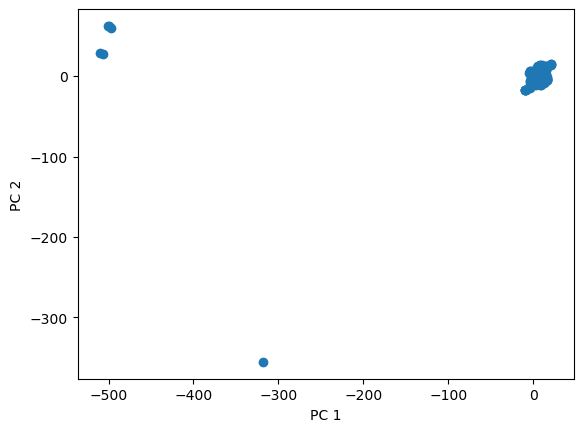

In [223]:
import matplotlib.pyplot as plt
plt.clf()

plt.scatter(comp[:, 0], comp[:, 1])
plt.xlabel('PC 1'), plt.ylabel('PC 2')
plt.show()

#plt.plot(pca.explained_variance_)
#plt.yscale('log')

In [224]:
#A selection made after training the pca, there are 5 eggregious outliers to exclude
not_outlier = np.in1d(np.arange(vectorized_frames.shape[0]), np.where(np.abs(comp[:, 0]) > 100)[0], invert=True)

In [225]:
from sklearn.decomposition import PCA
pca = PCA()
comp = pca.fit_transform(vectorized_frames[not_outlier])
print(comp[:, 0].mean(), comp[0, :].mean(), comp[:, 1].mean(), comp[1, :].mean())
print(comp[:, 0].std(), comp[0, :].std(), comp[:, 1].std(), comp[1, :].std())

codes_retained = []
for is_not_outlier, pdb_code in zip(not_outlier, [key for key, val in filter_selected_backbone]):
    if is_not_outlier:
        codes_retained.append(pdb_code)
    else:
        print(pdb_code, 'was dropped')

1.0010322e-05 -0.08135493 -9.87129e-06 -0.07140678
14.607394 1.5952064 10.075905 1.5499871
5XR8 was dropped
6OS0 was dropped
6OS1 was dropped
6OS2 was dropped
7C61 was dropped
7V3Z was dropped


In [249]:
species_labels = [structure_data[pdb_code]['species'] for pdb_code in codes_retained]
state_labels = [structure_data[pdb_code]['state'] for pdb_code in codes_retained]

In [315]:
np.unique(species_labels, return_counts=True)

(array(['Bos taurus', 'Canis lupus familiaris', 'Cavia porcellus',
        'Danio rerio', 'Homo sapiens', 'Human cytomegalovirus',
        'Meleagris gallopavo', 'Mus musculus', 'Rattus norvegicus',
        'Todarodes pacificus'], dtype='<U22'),
 array([ 34,   1,   1,   1, 347,   5,  24,   7,  14,   5]))

In [237]:
color_spec = {}
i, j = 0, 0.5
n_specs = np.unique(species_labels).shape[0]
for i, spec in enumerate(np.unique(species_labels)):
    r = (i+1)/n_specs
    g = 0.25
    b = 0.75 * (n_specs - i) / n_specs
    color_spec[spec] = (r, g, b)

In [241]:
color_spec['Homo sapiens'] = (0.8, 0.8, 0.2)

In [252]:
np.unique(state_labels)

array(['Active', 'Inactive', 'Intermediate'], dtype='<U12')

In [311]:
marker_spec = {'Active': '^',
               'Inactive': 'v',
               'Intermediate': 's'}

color_spec2 = {'Active': (0.1, 0.6, 0.1),
               'Inactive': (0.6, 0.1, 0.1),
               'Intermediate': (0.1, 0.1, 0.6)}

In [312]:
homos = np.where([label == 'Homo sapiens' for label in species_labels])[0]

<Figure size 640x480 with 0 Axes>

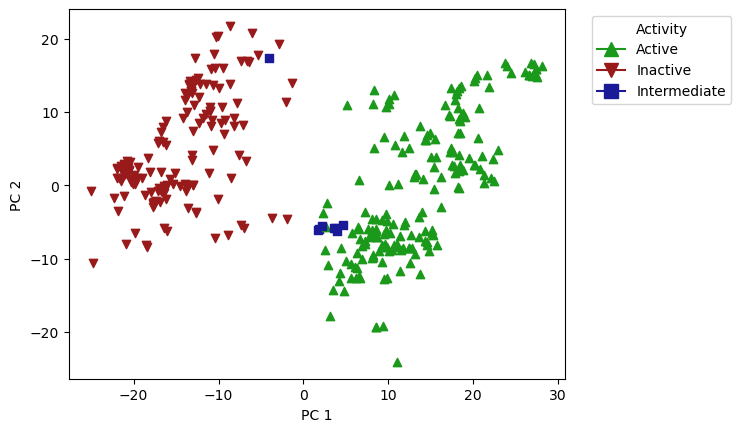

In [314]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


plt.clf()
fig, ax = plt.subplots()

# Create one proxy patch per cluster
#handles = [mpatches.Patch(color=color, label=f"{species}") for species, color in color_spec.items()]
marker_handles = [Line2D([0], [0], marker=marker, color=color_spec2[activity], markersize=10, label=activity) for activity, marker in marker_spec.items()]
for i, (x, y, col, mark) in enumerate(zip(comp[:, 0], comp[:, 1],
                                          [color_spec2[state] for state in state_labels],
                                          [marker_spec[state] for state in state_labels])):
    if np.any(homos == i):
        ax.scatter(x, y, marker=mark, color=col)

# legend1 = ax.legend(handles=handles,
#                     bbox_to_anchor=(1.35, 0.67),  # x > 1 pushes it to the right
#                     loc='upper right',           # anchor point on the legend box
#                     title='Species')

# ax.add_artist(legend1)

legend2 = ax.legend(handles=marker_handles,
                    bbox_to_anchor=(1.35,1.0),
                    loc='upper right',
                    title='Activity')


plt.xlabel('PC 1'), plt.ylabel('PC 2')
#plt.tight_layout()
plt.show()

In [316]:
import joblib
joblib.dump(pca, "pca_human.joblib")
# Load later and transform new data
pca = joblib.load("pca_human.joblib")
#X_new_transformed = pca.transform(X_new)